## Simple Baseline Models — Regional Weather

Same as `simpleModels.ipynb` but uses per-station weather features and cyclical calendar encoding.

- **No lags** — current-hour features only (29 features)
- **With lags** — adds lag-1h / lag-24h / lag-72h / lag-168h / lag-336h (34 features)
- **Data:** `combined_hourly_regional.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

DATA = '../../data/processed/combined_hourly_regional.csv'

STATIONS     = ['sacramento', 'sanjose', 'fresno', 'la']
WEATHER_VARS = ['temperature_c', 'precipitation_mm', 'solar_radiation_wm2', 'windspeed_ms', 'humidity_pct']
WEATHER_COLS = [f'{s}_{v}' for s in STATIONS for v in WEATHER_VARS]  # 20 cols

OTHER_FEATURES = ['gas_price_mmbtu', 'is_holiday', 'is_weekend',
                  'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']

FEATURES   = WEATHER_COLS + OTHER_FEATURES  # 29 total
SCALE_COLS = ['load_mw', 'gas_price_mmbtu'] + WEATHER_COLS
TARGET     = 'load_mw'

### 1. Load & lag features

In [2]:
df = pd.read_csv(DATA, parse_dates=['datetime'], index_col='datetime')

# Cyclical calendar encoding
df['hour_sin']  = np.sin(2 * np.pi * df.index.hour / 24)
df['hour_cos']  = np.cos(2 * np.pi * df.index.hour / 24)
df['dow_sin']   = np.sin(2 * np.pi * df.index.dayofweek / 7)
df['dow_cos']   = np.cos(2 * np.pi * df.index.dayofweek / 7)
df['month_sin'] = np.sin(2 * np.pi * df.index.month / 12)
df['month_cos'] = np.cos(2 * np.pi * df.index.month / 12)

df['load_lag1']   = df[TARGET].shift(1)
df['load_lag24']  = df[TARGET].shift(24)
df['load_lag72']  = df[TARGET].shift(72)
df['load_lag168'] = df[TARGET].shift(168)
df['load_lag336'] = df[TARGET].shift(336)
df = df.dropna()
print(f'{len(df):,} rows')

52,283 rows


### 2. Split then standardise (train stats only)

In [3]:
split = int(len(df) * 0.8)
train_raw, test_raw = df.iloc[:split].copy(), df.iloc[split:].copy()
print(f'Train: {len(train_raw):,}  {train_raw.index[0].date()} to {train_raw.index[-1].date()}')
print(f'Test:  {len(test_raw):,}   {test_raw.index[0].date()} to {test_raw.index[-1].date()}')

LAG_SCALE = SCALE_COLS + ['load_lag1', 'load_lag24', 'load_lag72', 'load_lag168', 'load_lag336']
scaler = {col: {'mean': train_raw[col].mean(), 'std': train_raw[col].std()}
          for col in LAG_SCALE}

train, test = train_raw.copy(), test_raw.copy()
for col, s in scaler.items():
    train[col] = (train[col] - s['mean']) / s['std']
    test[col]  = (test[col]  - s['mean']) / s['std']

load_mean = scaler['load_mw']['mean']
load_std  = scaler['load_mw']['std']
print(f'load_mw  mean={load_mean:.1f} MW  std={load_std:.1f} MW  (train only)')

LAG_FEATURES  = FEATURES + ['load_lag1', 'load_lag24', 'load_lag72', 'load_lag168', 'load_lag336']
X_train_base, X_test_base = train[FEATURES],     test[FEATURES]
X_train_lag,  X_test_lag  = train[LAG_FEATURES], test[LAG_FEATURES]
y_train, y_test            = train[TARGET],       test[TARGET]

Train: 41,826  2019-01-15 to 2023-10-23
Test:  10,457   2023-10-23 to 2024-12-31
load_mw  mean=24978.7 MW  std=4132.1 MW  (train only)


### 3. Fit & evaluate

In [4]:
def evaluate(name, model, X_test, y_test):
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae  = mean_absolute_error(y_test, pred)
    r2   = r2_score(y_test, pred)
    print(f'{name}')
    print(f'  RMSE  {rmse:.4f}  ({rmse * load_std:.0f} MW)')
    print(f'  MAE   {mae:.4f}  ({mae  * load_std:.0f} MW)')
    print(f'  R2    {r2:.4f}')
    print()
    return pred

lr_base = LinearRegression().fit(X_train_base, y_train)
lr_lag  = LinearRegression().fit(X_train_lag,  y_train)

pred_base = evaluate('Linear Regression Regional (no lags)',   lr_base, X_test_base, y_test)
pred_lag  = evaluate('Linear Regression Regional (with lags)', lr_lag,  X_test_lag,  y_test)

Linear Regression Regional (no lags)
  RMSE  0.5163  (2133 MW)
  MAE   0.4044  (1671 MW)
  R2    0.7133

Linear Regression Regional (with lags)
  RMSE  0.1739  (719 MW)
  MAE   0.1335  (552 MW)
  R2    0.9675



### 4. Predictions vs actuals (first 2 weeks of test)

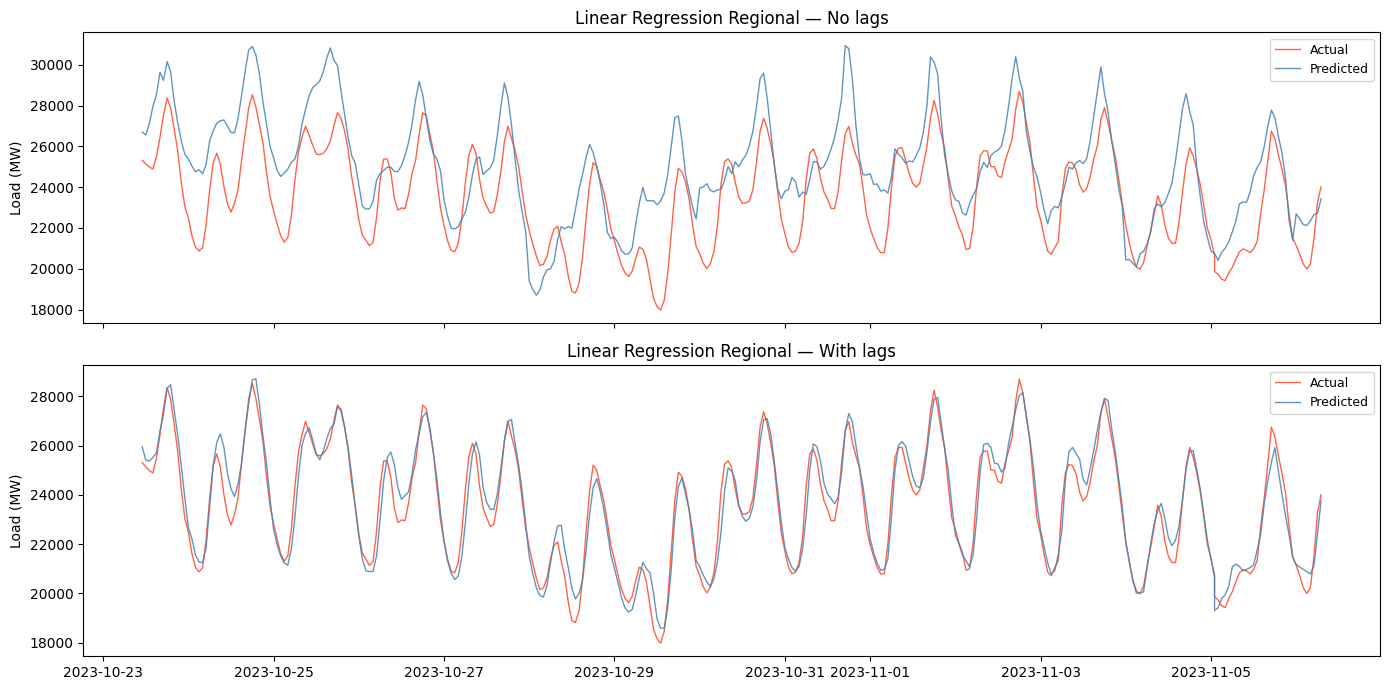

In [5]:
n      = 24 * 14
idx    = test.index[:n]
actual = y_test.values[:n] * load_std + load_mean

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for ax, pred, label in zip(axes, [pred_base[:n], pred_lag[:n]], ['No lags', 'With lags']):
    ax.plot(idx, actual,                      color='tomato',    linewidth=1,        label='Actual')
    ax.plot(idx, pred * load_std + load_mean, color='steelblue', linewidth=1, alpha=0.85, label='Predicted')
    ax.set_ylabel('Load (MW)')
    ax.set_title(f'Linear Regression Regional — {label}')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### 5. Feature coefficients (lag model)

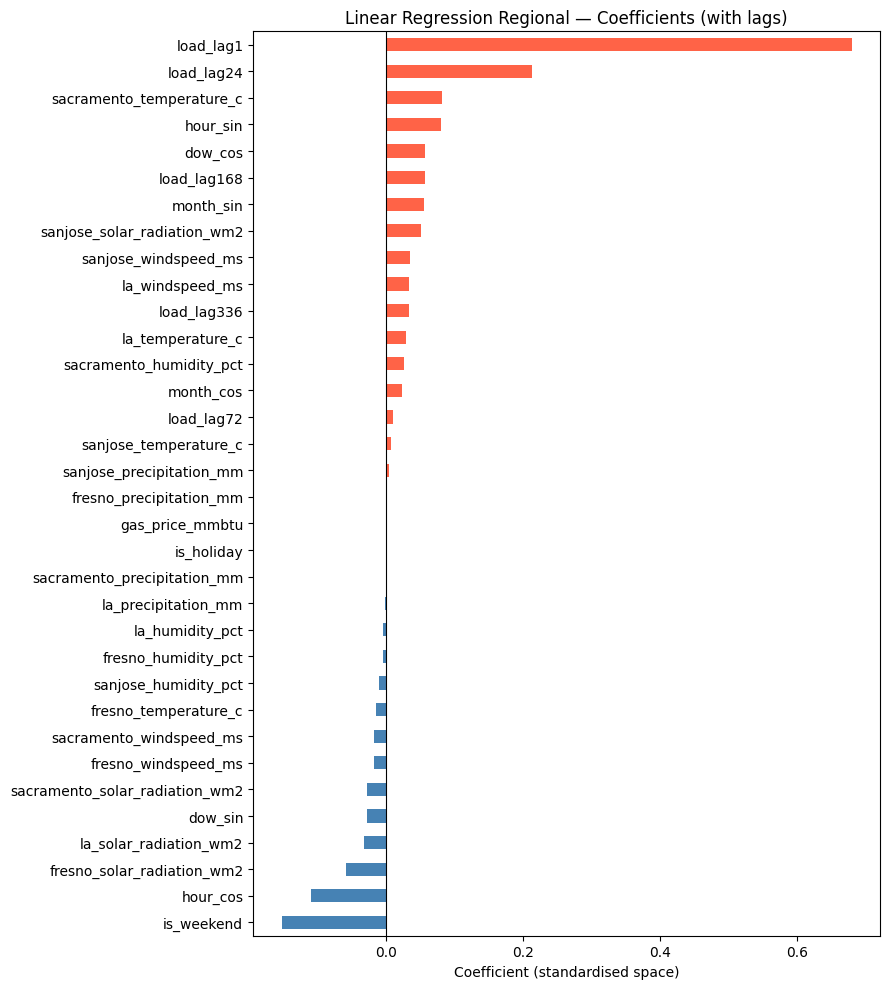

In [6]:
coef = pd.Series(lr_lag.coef_, index=LAG_FEATURES).sort_values()
colors = ['tomato' if c > 0 else 'steelblue' for c in coef]

fig, ax = plt.subplots(figsize=(9, 10))
coef.plot.barh(ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Linear Regression Regional — Coefficients (with lags)')
ax.set_xlabel('Coefficient (standardised space)')
plt.tight_layout()
plt.show()